# Analysis

Some network analysis stuff

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


### Data

In [10]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad')

In [11]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....
adata

AnnData object with n_obs × n_vars = 221273 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'

In [12]:
adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

# select only perturbations that are present in at least a certain number of cells
counts = adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
adata = adata[adata.obs['target_gene'].isin(valid_pert)]
del counts
del valid_pert
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

: 

In [6]:
gene_list = adata.var_names.tolist()

### network

In [7]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 8])


num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
adata

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


AnnData object with n_obs × n_vars = 220998 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [ ]:
import pickle

# grn for control data
with open("grn_coexpression_vcc_data.pkl", "rb") as file:
    G = pickle.load(file)
G.number_of_nodes()

In [12]:
genes_not_included = [gene for gene in gene_list if gene not in list(G.nodes)] # some genes of gene_list are not included!
G.add_nodes_from(genes_not_included)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1

#TODO: I should recompute the GRN....
nodes_to_remove = [node for node in G.nodes() if node not in gene_list]
G.remove_nodes_from(nodes_to_remove)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


In [29]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names) == set(gene_list), "Nodes in G and adata.var_names differ!"

In [9]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

### Path length analysis

Counter({2: 1826931, 1: 461270, 3: 59631, 4: 4208})


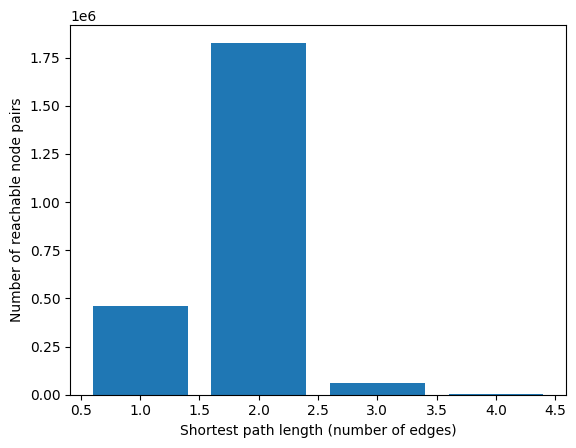

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

# G is your nx.DiGraph
length_counts = Counter()

for source, targets in nx.all_pairs_shortest_path_length(G):
    for target, dist in targets.items():
        if source != target:   # skip zero-length path from node to itself
            length_counts[dist] += 1

print(length_counts)
# example: Counter({1: 120, 2: 45, 3: 9})

# plot
plt.bar(length_counts.keys(), length_counts.values())
plt.xlabel("Shortest path length (number of edges)")
plt.ylabel("Number of reachable node pairs")
plt.show()

### Centrality

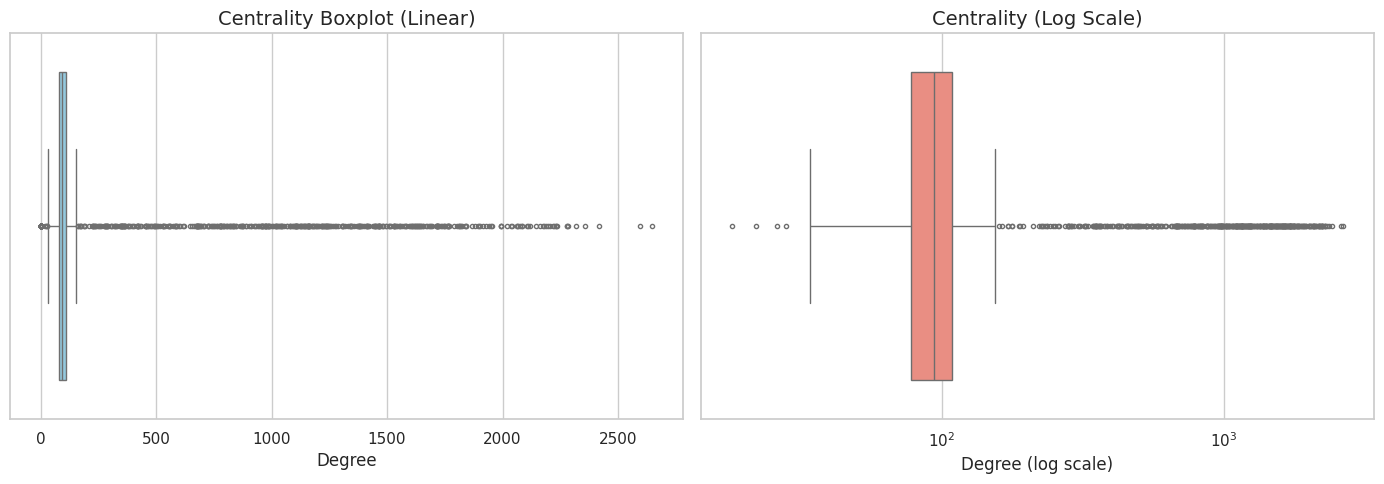

In [9]:
import seaborn as sns
from matplotlib import pyplot as plt


degrees = [d for n, d in G.degree()]
degrees = np.array(degrees)

# 2. Set up the figure
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Standard Linear Boxplot ---
sns.boxplot(x=degrees, ax=axes[0], color='skyblue', fliersize=3)
axes[0].set_title('Centrality Boxplot (Linear)', fontsize=14)
axes[0].set_xlabel('Degree')

# --- Plot 2: Log-Scale Boxplot ---
# Note: We use log_scale on the x-axis to spread out the low-degree nodes
sns.boxplot(x=degrees, ax=axes[1], color='salmon', fliersize=3)
axes[1].set_xscale('log')
axes[1].set_title('Centrality (Log Scale)', fontsize=14)
axes[1].set_xlabel('Degree (log scale)')

plt.tight_layout()
plt.show()

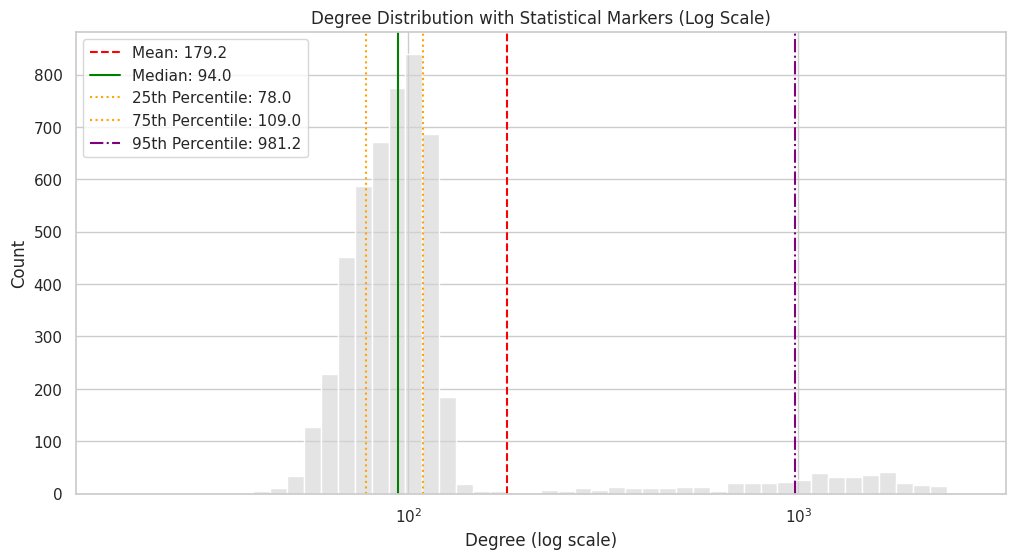

In [10]:
# 1. Calculate the statistics
degrees = [d for n, d in G.degree()]
mean_val = np.mean(degrees)
q25, median_val, q75 = np.quantile(degrees, [0.25, 0.5, 0.75])
q95 = np.quantile(degrees, 0.95) # Top 5% 'Hub' threshold

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.histplot(degrees, bins=50, log_scale=True, color='lightgray', alpha=0.6)

# 3. Add Vertical Lines
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')
plt.axvline(q25, color='orange', linestyle=':', label=f'25th Percentile: {q25:.1f}')
plt.axvline(q75, color='orange', linestyle=':', label=f'75th Percentile: {q75:.1f}')
plt.axvline(q95, color='purple', linestyle='-.', label=f'95th Percentile: {q95:.1f}')

plt.title('Degree Distribution with Statistical Markers (Log Scale)')
plt.xlabel('Degree (log scale)')
plt.ylabel('Count')
plt.legend()
plt.show()

Ahh, thats meaningful. Let's see about perturbation genes

here we consider just the centrality of the genes that are being perturbed:

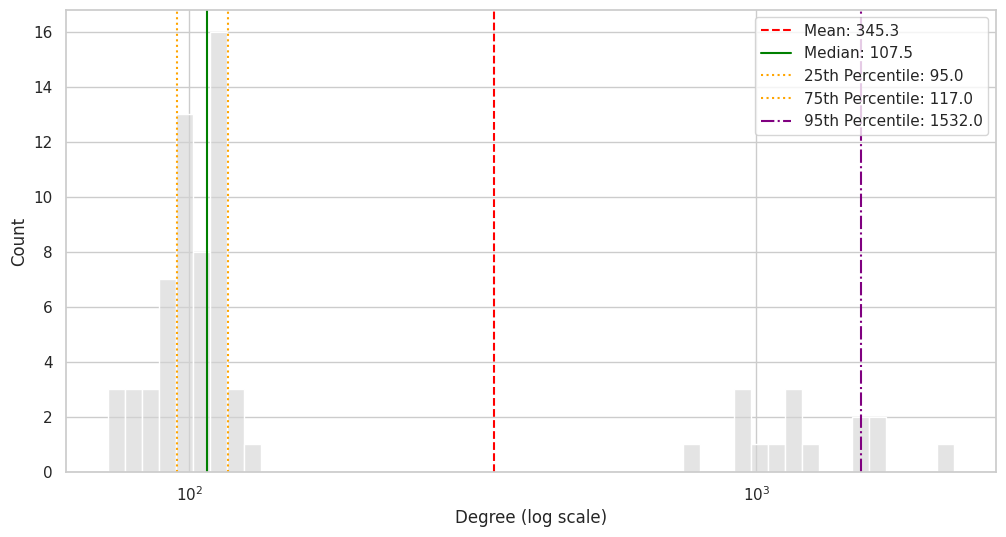

In [11]:
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')

selected_degrees = [d for n, d in G.degree() if n in perturbations]
mean_val = np.mean(selected_degrees)
q25, median_val, q75 = np.quantile(selected_degrees, [0.25, 0.5, 0.75])
q95 = np.quantile(selected_degrees, 0.95) # Top 5% 'Hub' threshold

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.histplot(selected_degrees, bins=50, log_scale=True, color='lightgray', alpha=0.6)

# 3. Add Vertical Lines
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')
plt.axvline(q25, color='orange', linestyle=':', label=f'25th Percentile: {q25:.1f}')
plt.axvline(q75, color='orange', linestyle=':', label=f'75th Percentile: {q75:.1f}')
plt.axvline(q95, color='purple', linestyle='-.', label=f'95th Percentile: {q95:.1f}')

plt.xlabel('Degree (log scale)')
plt.ylabel('Count')
plt.legend()
plt.show()

### Coexpression

In [ ]:
# returns a list of networks (one for each element of data_matrices)
from scipy.stats import spearmanr
from statsmodels.stats.multitest import fdrcorrection
import math
import anndata as ad

def build_spearman_networks(data_matrix: ad.AnnData, corr_threshold: float):

    # array of pvalues for the correlation of each pair of genes
    gene_names = data_matrix.var_names
    corr, p = spearmanr(data_matrix.X.toarray())
    
    # bonferroni correction
    #alpha = 0.05/math.comb(data_matrix.shape[1],2)

    _, pvals_corrected = fdrcorrection(p, alpha=0.05, method='indep')

    # only significant correlated genes
    coexpression_matrix = ((p<alpha)&(np.absolute(corr)>corr_threshold)).astype(int)
    #np.fill_diagonal(aus, 0)
    cexpression_graph = pd.DataFrame(coexpression_matrix, index=gene_names, columns=gene_names)
    return cexpression_graph

In [ ]:
adata_ctrl = adata[adata.obs['target_gene']=='non-targeting']

In [ ]:
coexpression_graph = build_spearman_networks(adata_ctrl, 0.1)
coexpression_graph

In [ ]:
G = nx.from_pandas_adjacency(coexpression_graph)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)


assert set(G.nodes) == set(adata.var_names) == set(gene_list), "Nodes in G and adata.var_names differ!"

# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

### GRNBoost2 network

In [ ]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/adjacencies.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.1: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

genes_not_included = [gene for gene in gene_list if gene not in list(G.nodes)] # some genes of gene_list are not included!
G.add_nodes_from(genes_not_included)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

nodes_to_remove = [node for node in G.nodes() if node not in gene_list]
G.remove_nodes_from(nodes_to_remove)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()


print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

### Correlation with centrality

In [ ]:
from scores import RobustDES
from tqdm import tqdm

perturbed_genes_degree_dict = {k: G.degree()[k] for k in perturbations}

adata_subset = adata[100000:,:]

des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

n_perturbed_genes = {}


for pert in tqdm(perturbations):
    if pert=='non-targeting':
        continue

    #DEGs
    df_true, _ = des_calculator.get_de_genes(adata_subset, 'target_gene', pert, 'non-targeting')
    G_true = set(df_true.index)
    n_true = len(G_true)
    n_perturbed_genes[pert]=n_true

 

In [ ]:
# filtering out outliers
for pert in tqdm(perturbations):
    if pert=='non-targeting':
        continue

    if n_perturbed_genes[pert] > 1000 or perturbed_genes_degree_dict[pert]>2000:
        
        del n_perturbed_genes[pert]
        del perturbed_genes_degree_dict[pert]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# mathing - We sort the keys to ensure we extract values in the exact same order
assert perturbed_genes_degree_dict.keys() == n_perturbed_genes.keys(), "keys don't match"
common_keys = sorted(perturbed_genes_degree_dict.keys()) 

# Create aligned lists
num_affected_edges_values = [perturbed_genes_degree_dict[k] for k in common_keys]
n_perturbed_genes_values = [n_perturbed_genes[k] for k in common_keys]

# correlation
corr_p, _ = pearsonr(num_affected_edges_values, n_perturbed_genes_values)

# Spearman: Use if you just care about rank (e.g. "if x is high, y is high")
corr_s, _ = spearmanr(num_affected_edges_values, n_perturbed_genes_values)

print(f"Pearson Correlation: {corr_p:.2f}")   # 1.0 is perfect match, 0 is no match
print(f"Spearman Correlation: {corr_s:.2f}")

# 3. VISUALIZATION
plt.figure(figsize=(10, 8))
plt.scatter(num_affected_edges_values, n_perturbed_genes_values, color='blue', alpha=0.7)

# Optional: Add labels to points
for i, key in enumerate(common_keys):
    plt.annotate(key, (num_affected_edges_values[i], n_perturbed_genes_values[i]), xytext=(5, 5), textcoords='offset points')

#plt.title('Correlation between affected edges in the GRN and DEGs')
plt.xlabel('Number of affected GRN edges')
plt.ylabel('number of DEGs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Correlation with affected edges

In [25]:
from scores import RobustDES
from tqdm import tqdm

des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

num_affected_edges = {}
n_perturbed_genes = {}

condition = adata.obs['target_gene'].unique()

for pert in tqdm(condition):
    if pert=='non-targeting':
        continue

    # list of the perturbed genes indices - saved in self.perturb_map
    perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx]
    perturbs = torch.tensor(perturbs, dtype=torch.long)

    # true for all the elements of edge_index[1] that are in perturb_map[gene_str]
    mask = torch.isin(edge_index[1], perturbs) 
    num_affected_edges[pert] = mask.sum().item()

    #DEGs
    df_true, _ = des_calculator.get_de_genes(adata, 'target_gene', pert, 'non-targeting')
    G_true = set(df_true.index)
    n_true = len(G_true)
    n_perturbed_genes[pert]=n_true

    # NOTE: david suggestion - remove outliers
    # if n_true > 1000 & num_affected_edges[pert]>500:
    #     del n_perturbed_genes[pert]
    #     del num_affected_edges[pert]


100%|██████████| 146/146 [29:17<00:00, 12.04s/it]


In [33]:
for pert in tqdm(condition):
    if pert=='non-targeting':
        continue

    # list of the perturbed genes indices - saved in self.perturb_map
    perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx]
    perturbs = torch.tensor(perturbs, dtype=torch.long)

    # true for all the elements of edge_index[1] that are in perturb_map[gene_str]
    mask = torch.isin(edge_index[1], perturbs) 
    num_affected_edges[pert] = mask.sum().item()

    #DEGs
    # df_true, _ = des_calculator.get_de_genes(adata, 'target_gene', pert, 'non-targeting')
    # G_true = set(df_true.index)
    # n_true = len(G_true)
    # n_perturbed_genes[pert]=n_true

    # NOTE: david suggestion - remove outliers
    # if n_true > 1000 & num_affected_edges[pert]>500:
    #     del n_perturbed_genes[pert]
    #     del num_affected_edges[pert]

100%|██████████| 146/146 [00:00<00:00, 701.44it/s]


Pearson Correlation: 0.01
Spearman Correlation: -0.01


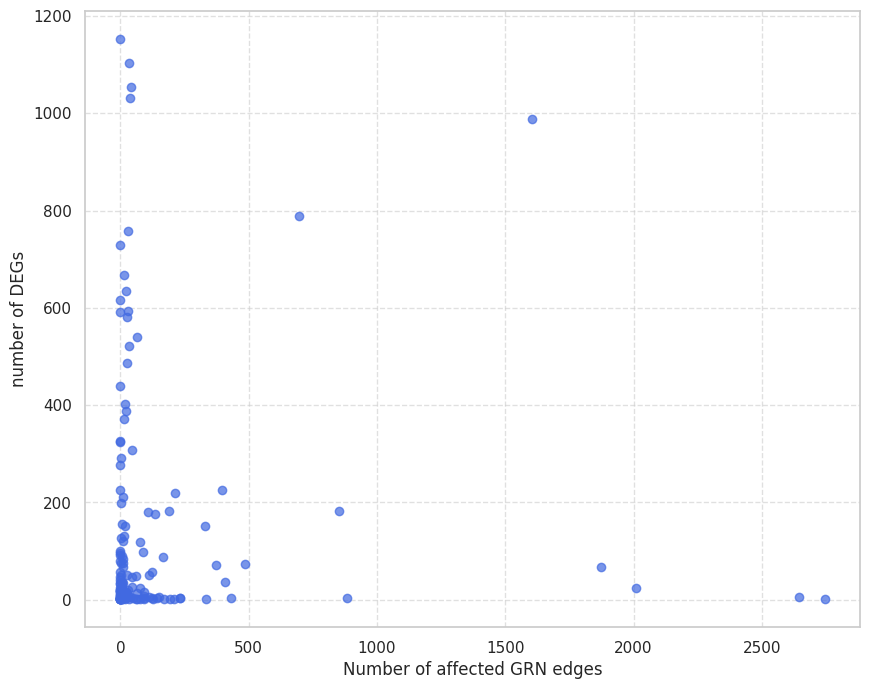

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# mathing - We sort the keys to ensure we extract values in the exact same order
assert num_affected_edges.keys() == n_perturbed_genes.keys(), "keys don't match"
common_keys = sorted(num_affected_edges.keys()) 

# Create aligned lists
num_affected_edges_values = [num_affected_edges[k] for k in common_keys]
n_perturbed_genes_values = [n_perturbed_genes[k] for k in common_keys]

# correlation
corr_p, _ = pearsonr(num_affected_edges_values, n_perturbed_genes_values)

# Spearman: Use if you just care about rank (e.g. "if x is high, y is high")
corr_s, _ = spearmanr(num_affected_edges_values, n_perturbed_genes_values)

print(f"Pearson Correlation: {corr_p:.2f}")   # 1.0 is perfect match, 0 is no match
print(f"Spearman Correlation: {corr_s:.2f}")

# 3. VISUALIZATION
plt.figure(figsize=(10, 8))
plt.scatter(num_affected_edges_values, n_perturbed_genes_values, color='royalblue', alpha=0.7)
# plt.yscale('log')
# plt.xscale('log')

#plt.title('Correlation between affected edges in the GRN and DEGs')
plt.xlabel('Number of affected GRN edges')
plt.ylabel('number of DEGs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('corr_plot.pdf')
plt.show()